# Programming Assignment 8

The goal of this assignment is to build familiarity with Cartopy by replicating some figures as closely as possible.

The assignment contains some cells that obtain data over the internet that you need to work with. Don't worry about how this code works. It will give you some numpy arrays, which you will use. 

***You may not use any packages other than Cartopy, Matplotlib and NumPy to complete this assignment. Use only the functions introduced in class notebooks, but you may use additional arguments and keywords for those functions.***

***Reviewing Cartopy and Matplotlib class notebook will help complete this assignment.*** Here are some additional resources

* [Matplotlib cheatsheets](https://matplotlib.org/cheatsheets/)
* [`subplots` reference](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.subplots.html)
* [`scatter` reference](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.scatter.html)


#### Basic and Advanced figures
Full credit will be given for recreating the Basic figure in each task below. A small bonus will be given for recreating the Advanced figure, but you will learn some more advanced Cartopy and Matplotlib capabilities. Pick *either* the Basic or Advanced figure, so your submitted notebook produces just one figure per part. 

# 0. Preliminary

Import cartopy.crs, cartopy.feature and matplotlib.pyplot here, using the customary aliases for each.

In [ ]:
# Write your code here

# 1. Mapping points

This task will map earthquakes from a USGS catalog of historic large earthquakes. It's the same dataset that you worked with previously, but now displayed on a map.

Recreate either the Basic or Advanced figure below.

Tips
* The figure size is 6x4 inches.
* The map is Albers Equal Area, using projection parameters and extents given in the 10-maps.ipynb notebook.
* For the Advanced figure, the background image is the NASA "BlueMarble_NextGeneration".

#### Basic figure
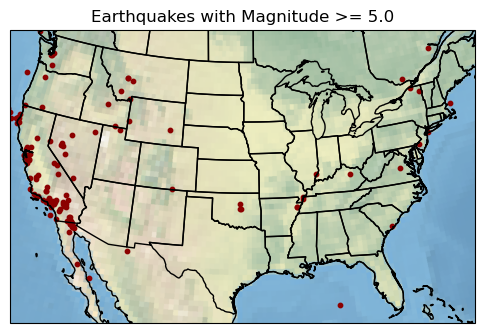
#### Advanced figure
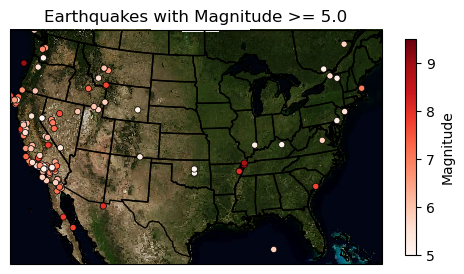

In [ ]:
# Do not modify this cell
import numpy as np
import pooch
fname = pooch.retrieve(
    "https://rabernat.github.io/research_computing/signif.txt.tsv.zip",
    known_hash='22b9f7045bf90fb99e14b95b24c81da3c52a0b4c79acf95d72fbe3a257001dbb',
    processor=pooch.Unzip()
)[0]

earthquakes = np.genfromtxt(fname, delimiter='\t')
depth = earthquakes[:, 8]
magnitude = earthquakes[:, 9]
latitude = earthquakes[:, 20]
longitude = earthquakes[:, 21]

# Select only earthquakes with magnitude >= 5.0
mask = magnitude >= 5.0
magnitude = magnitude[mask]
depth = depth[mask]
latitude = latitude[mask]
longitude = longitude[mask]

In [ ]:
# Write your code here
# Use these variables defined in the cell above: latitude, longitude, magnitude, depth

# 2. Sea ice concentration

### Background
The NOAA Daily Optimum Interpolation Sea Surface Temperature (OISST) is a long term Climate Data Record that incorporates observations from different platforms (satellites, ships, buoys and Argo floats) into a regular global grid. The dataset is interpolated to fill gaps on the grid and create a spatially complete map of sea surface temperature and sea ice concentration. Satellite and ship observations are referenced to buoys to compensate for platform differences and sensor biases.

### Task 2a.

Recreate either the Basic or Advanced figure below.

Tips
* The figure size is 6x3 inches.
* Use `cfeature.LAND` for filled land.
* For the Advanced figure, use the `zorder` keyword for plotting commands to ensure the land appears on top of the other figure elements. Here is a [zorder tutorial](https://matplotlib.org/stable/gallery/misc/zorder_demo.html).

#### Basic figure
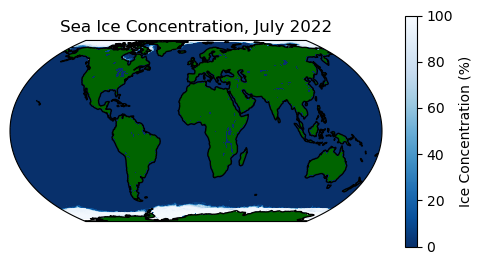
#### Advanced figure
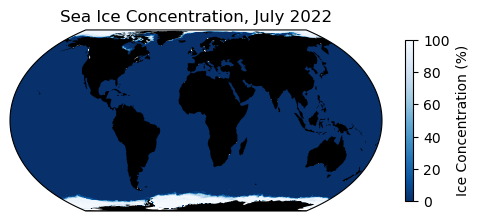

In [ ]:
# Don't modify this cell
import xarray as xr

# 1° OISST
ds = xr.open_dataset('http://psl.noaa.gov/thredds/dodsC/Datasets/noaa.oisst.v2/icec.mnmean.nc').sel(time='2022-07-01')
ice_conc = ds['icec'].values
ice_lon = ds['lon'].values
ice_lat = ds['lat'].values

# You will use the arrays ice_conc, ice_lon, and ice_lat

In [ ]:
# Write your code here
# Use these variables defined in the cell above: ice_conc, ice_lon, ice_lat

### Task 2b
Sea ice is found only in the Arctic and Antarctic, so the global map above isn't the best way to display the sea ice concentrations.

Recreate either the Basic or Advanced figure below showing ice in the Arctic (Basic and Advanced) and Antarctic (Advanced only).

Tips
* The Basic figure size is 4x4 inches. The Advanced figure size is 8x4 inches.
* For the Advanced figure, create the colorbar with `ax=[ax0,ax1]` so that the colorbar is linked to both panels.

#### Basic figure
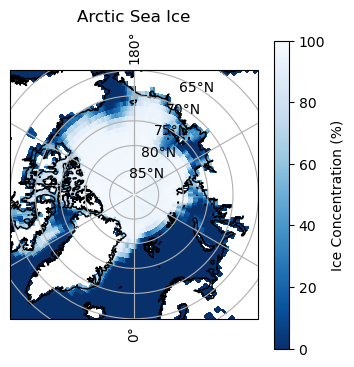
#### Advanced figure
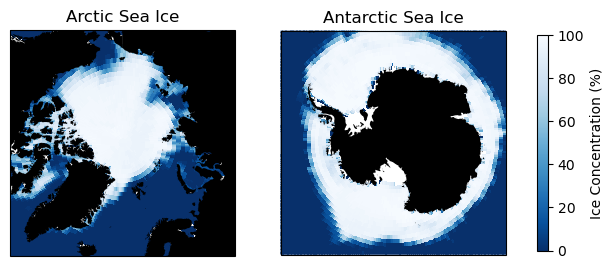

In [ ]:
# Write your code here
# Use these variables defined in the cell above: ice_conc, ice_lon, ice_lat

## 3 Gradients and Geostrophic wind

In this task, you will compute the geostrophic wind ($u_g, v_g$) from geopotential height ($Z$).

The geostrophic wind equations are
$$ v_g = \frac{g}{f_c} \frac{\partial Z}{\partial x}  $$
$$ u_g = -\frac{g}{f_c} \frac{\partial Z}{\partial y}  $$
where $Z$ is geopotential height, $g = 9.81 {\rm m\, s^{-2}}$, and $f_c$ is the Coriolis parameter. In this task, use a value $f_c \approx 10^{-4} {\rm s^{-1}}$, which is representative of the northern mid-latitudes.

This diagram shows geopotential height that will be used in this task, representing the 500 hPa heights in the northern mid-latitudes.
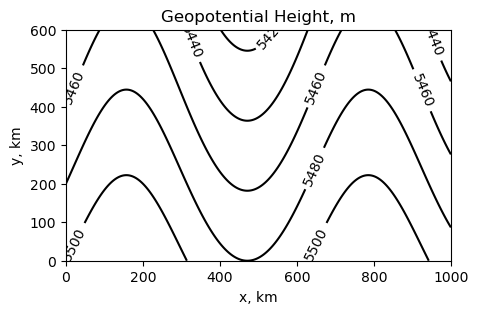

Do the following:
1. Print the dimensions of the x, y, and Z arrays.
1. Compute the derivative dZ/dx using the centered finite differences for interior points and forward/backward finite difference for the borders. The code to do this is in the 08-numpy.ipynb notebook. Your values should be in the range -2.6e-4 to +2.6e-4 (unitless or m/m).
1. Compute $v_g$ using your values of dZ/dx. Your values should be in the range -25.5 m/s to +25.5 m/s.
1. Compute the derivative dZ/dy using finite differences, by copying and adapting your code for dZ/dx. Your values should be in the range -1.1e-4 to -9e-5.
1. Compute $u_g$. Your values should be int he range 8.8 m/s to 10.8 m/s.
1. Recreate the figure below. Your contour labels don't need to match the figure 

#### Basic figure
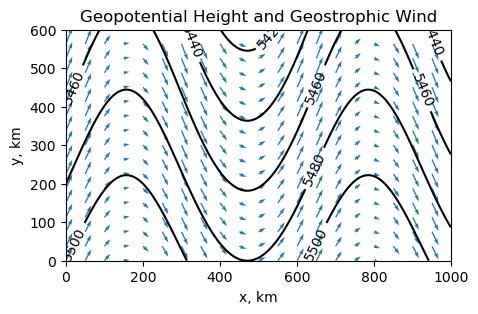

Tips:
* The figure size is 5x3 inches.
* For the red arrows, sample every 50th point. See quiver example in 09-matplotlib notebook
* Use `ax.set_aspect('equal')` to make the x and y axes have the same scale.

#### Advanced figure
* Make the contour labels in the Basic figure match the example.
* Reproduce the following figure as well. 
* The figure below is 10x4 inches. 
* The streamplot lines are colored by wind speed.
* The barbs are subsampled every 100th point.

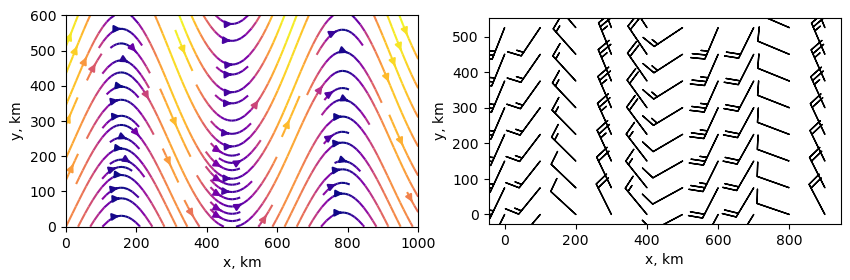

In [ ]:
# Don't modify this cell
# Load geopotential height (Z) data and its coordinates (x, y)
data = np.load('prog08_files/geopotential_height.npz')
x = data['x']
y = data['y']
Z = data['Z']

In [ ]:
# Write your code here
# Use these variables defined in the cell above: x, y, Z
# All these variables have units of meters